# Setup

Load libaries and define paths

In [1]:
import numpy as np
import nibabel as nib
import glob
import os
import warnings
import imageio
from sklearn.exceptions import ConvergenceWarning
from sklearn.decomposition import NMF
import matplotlib.pyplot as plt
import pickle
import pandas as pd
from collections import defaultdict
from scipy.cluster.hierarchy import linkage, cophenet
from scipy.spatial.distance import squareform
from scipy.optimize import linear_sum_assignment
from nilearn import plotting
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# make project dir our working directory
to_proj = "/Users/ha5133ba/Documents/projects/mtl-tau"
os.chdir(to_proj)

# path to mni template
mni_path = "/Users/ha5133ba/Documents/resources/templates/tpl-MNI152NLin2009cAsym_res-01_T1w.nii.gz"

# set to True to rerun NMF, False to load saved results
RERUN_NMF = False

/Users/ha5133ba/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Load external objects

In [2]:
# load binary mtl mask
mask      = nib.load(os.path.join(to_proj, "data/adnidod/MTL_mask_80pct_MNI.nii.gz"))
mask_data = np.asarray(mask.dataobj).astype(bool)

# select baseline (earliest) tau pet scan per subject
files = sorted(glob.glob("data/adnidod/tau-pet_mni_masked/*.nii.gz"))
print(f"Total scans found : {len(files)}")

subject_files = defaultdict(list)
for f in files:
    sub_id = os.path.basename(f).split('_')[0]
    subject_files[sub_id].append(f)

# ses-YYYYMMDD sorts chronologically so first = earliest
files_baseline = [sorted(sub_files)[0]
                  for _, sub_files in sorted(subject_files.items())]

print(f"Unique subjects   : {len(files_baseline)}")

Total scans found : 149
Unique subjects   : 97


# NMF

In [3]:
nmf_path = "results/nmf_results.pkl"

## Prepare data

In [4]:
# build data matrix for nmf
X = []
filenames = []

for f in files_baseline:
    img = nib.load(f)
    data = np.asarray(img.dataobj)
    X.append(data[mask_data])
    filenames.append(f)

X = np.array(X)
print(f"Data matrix shape: {X.shape}")

Data matrix shape: (97, 15749)


## Inspect data

NaN values  : 0
Inf values  : 0
Min / Max   : 0.000 / 2.523
Mean SUVR   : 1.109

Per-subject mean SUVR: min=0.802, max=1.526

Outlier subjects (>3 SD): 1
  Outlier 1: mean SUVR = 1.526


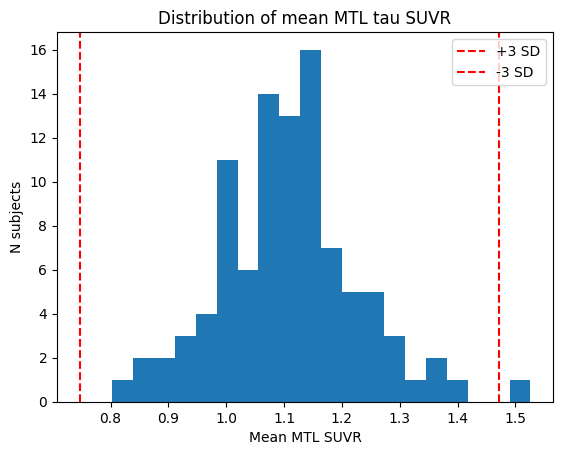

In [5]:
# basic data quality
print(f"NaN values  : {np.isnan(X).sum()}")
print(f"Inf values  : {np.isinf(X).sum()}")
print(f"Min / Max   : {X.min():.3f} / {X.max():.3f}")
print(f"Mean SUVR   : {X.mean():.3f}")

# check for subjects with suspicious values (e.g. all zeros or very high)
row_means = X.mean(axis=1)
print(f"\nPer-subject mean SUVR: min={row_means.min():.3f}, max={row_means.max():.3f}")

# flag outliers (e.g. > 3 SD from mean)
z = (row_means - row_means.mean()) / row_means.std()
outliers = [(filenames[i], row_means[i]) for i in np.where(np.abs(z) > 3)[0]]
print(f"\nOutlier subjects (>3 SD): {len(outliers)}")
for i, (f, m) in enumerate(outliers):
    print(f"  Outlier {i+1}: mean SUVR = {m:.3f}")

# visualize distribution of mean SUVR across subjects
threshold_upper = row_means.mean() + 3 * row_means.std()
threshold_lower = row_means.mean() - 3 * row_means.std()

plt.hist(row_means, bins=20)
plt.axvline(threshold_upper, color='red', linestyle='--', label='+3 SD')
plt.axvline(threshold_lower, color='red', linestyle='--', label='-3 SD')
plt.xlabel("Mean MTL SUVR")
plt.ylabel("N subjects")
plt.title("Distribution of mean MTL tau SUVR")
plt.legend()
plt.show()

*We don't care about outliers right now, but should discuss a strategy for dealing with these later*

In [6]:
# ensure non-negative input
X_nn = np.clip(X, 0, None)

## Run analyses

### Helpers

In [7]:
def run_nmf(X, k, random_state=1909):
    nmf = NMF(n_components=k, init='random', max_iter=1000, random_state=random_state)
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning) # we are suppressing convergence warnings for now (low n)
        warnings.filterwarnings("ignore", category=RuntimeWarning)
        W = nmf.fit_transform(X)
    H = nmf.components_
    return W, H, nmf.reconstruction_err_

def nmf_stability(X, k, n_runs=20):
    connectivity_matrices = []
    for seed in range(n_runs):
        nmf = NMF(n_components=k, init='random', max_iter=1000, random_state=seed)
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=ConvergenceWarning)
            warnings.filterwarnings("ignore", category=RuntimeWarning)
            W = nmf.fit_transform(X)
        labels = W.argmax(axis=1)
        conn = (labels[:, None] == labels[None, :]).astype(float)
        connectivity_matrices.append(conn)
    avg_conn = np.mean(connectivity_matrices, axis=0)
    dist = 1 - avg_conn
    np.fill_diagonal(dist, 0)
    Z = linkage(squareform(dist), method='average')
    coph, _ = cophenet(Z, squareform(dist))
    return coph

def nmf_split_half_reproducibility(X, k, n_splits=100, random_state=1909):
    rng = np.random.default_rng(random_state)
    correlations = []

    for _ in range(n_splits):
        # random split
        idx = rng.permutation(X.shape[0])
        half = len(idx) // 2
        X1 = X[idx[:half]]
        X2 = X[idx[half:]]

        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=ConvergenceWarning)
            warnings.filterwarnings("ignore", category=RuntimeWarning)
            nmf1 = NMF(n_components=k, init='random', max_iter=1000,
                       random_state=int(rng.integers(1000)))
            nmf2 = NMF(n_components=k, init='random', max_iter=1000,
                       random_state=int(rng.integers(1000)))
            nmf1.fit_transform(X1)
            nmf2.fit_transform(X2)

        H1 = nmf1.components_  # shape (k, n_voxels)
        H2 = nmf2.components_

        # compute correlation matrix between all component pairs
        corr_matrix = np.corrcoef(H1, H2)[:k, k:]

        # optimal matching using Hungarian algorithm
        row_ind, col_ind = linear_sum_assignment(-corr_matrix)
        mean_corr = corr_matrix[row_ind, col_ind].mean()
        correlations.append(mean_corr)

    return np.mean(correlations), np.std(correlations)

### Test *k*-range

In [8]:
k_range = range(2, 9)
errors, stabilities, repro_means, repro_stds = [], [], [], []

if RERUN_NMF or not os.path.exists(nmf_path):
    print("Running NMF...")
    nmf_results = {}
    for k in k_range:
        W, H, err = run_nmf(X_nn, k)
        stab = nmf_stability(X_nn, k)
        repro_mean, repro_std = nmf_split_half_reproducibility(X_nn, k)
        nmf_results[k] = {"W": W, "H": H, "err": err,
                          "stability": stab,
                          "repro_mean": repro_mean,
                          "repro_std": repro_std}
    with open(nmf_path, "wb") as f:
        pickle.dump(nmf_results, f)
    print(f"Saved to {nmf_path}")
else:
    with open(nmf_path, "rb") as f:
        nmf_results = pickle.load(f)
    print(f"Loaded from {nmf_path}")

# populate metric lists from nmf_results (works for both run and load)
for k in k_range:
    errors.append(nmf_results[k]["err"])
    stabilities.append(nmf_results[k]["stability"])
    repro_means.append(nmf_results[k]["repro_mean"])
    repro_stds.append(nmf_results[k]["repro_std"])

Loaded from results/nmf_results.pkl


## Component selection

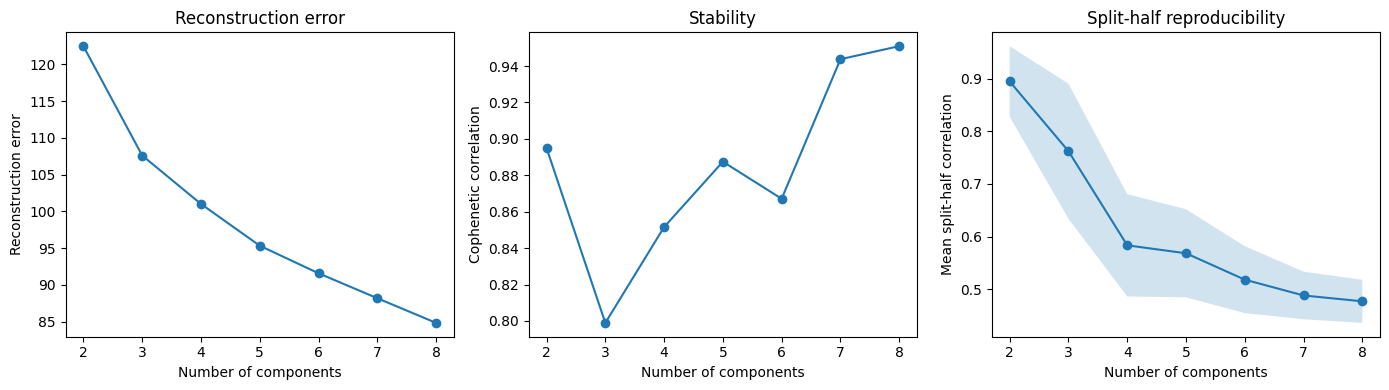

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(k_range, errors, 'o-')
axes[0].set_xlabel("Number of components")
axes[0].set_ylabel("Reconstruction error")
axes[0].set_title("Reconstruction error")

axes[1].plot(k_range, stabilities, 'o-')
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cophenetic correlation")
axes[1].set_title("Stability")

axes[2].plot(k_range, repro_means, 'o-')
axes[2].fill_between(k_range,
                     np.array(repro_means) - np.array(repro_stds),
                     np.array(repro_means) + np.array(repro_stds),
                     alpha=0.2)
axes[2].set_xlabel("Number of components")
axes[2].set_ylabel("Mean split-half correlation")
axes[2].set_title("Split-half reproducibility")

plt.tight_layout()
plt.show()

### Explore solution(s)

Let's look at k = 2 and 3 more closely here

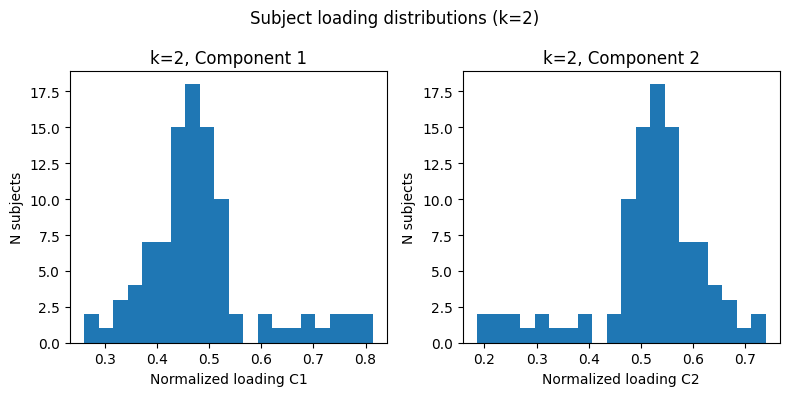

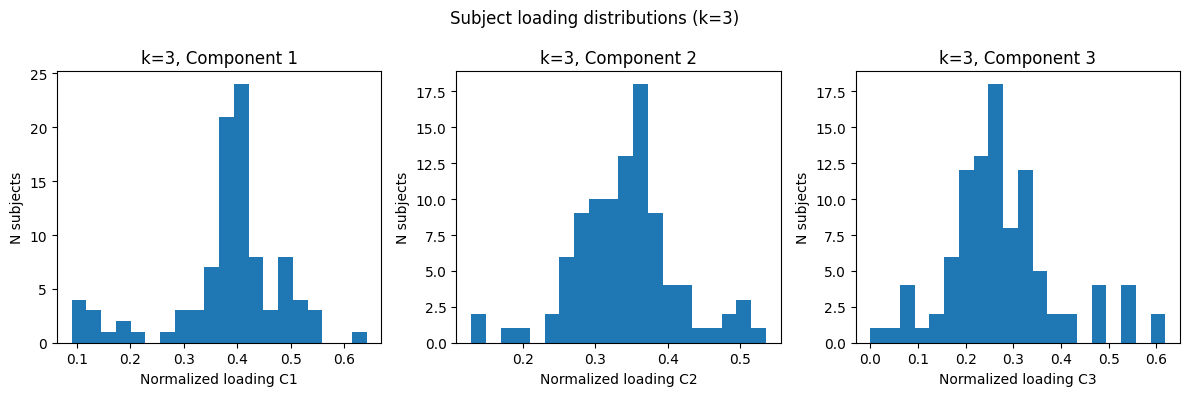

In [10]:
for k_best in [2, 3]:
    W, H, err = run_nmf(X_nn, k_best)
    
    df = pd.DataFrame(W, columns=[f"C{i+1}" for i in range(k_best)])
    
    # normalize loadings to sum to 1 per subject
    df_norm = df.div(df.sum(axis=1), axis=0)
    
    fig, axes = plt.subplots(1, k_best, figsize=(4 * k_best, 4))
    for i, ax in enumerate(axes):
        ax.hist(df_norm[f"C{i+1}"], bins=20)
        ax.set_xlabel(f"Normalized loading C{i+1}")
        ax.set_ylabel("N subjects")
        ax.set_title(f"k={k_best}, Component {i+1}")
    plt.suptitle(f"Subject loading distributions (k={k_best})")
    plt.tight_layout()
    plt.show()

Check distribution of dominant components

In [11]:
for k_best in [2, 3]:
    print(f"{k_best} components")
    W, H, err = run_nmf(X_nn, k_best)
    dominant = W.argmax(axis=1) + 1
    for c in range(1, k_best + 1):
        n = (dominant == c).sum()
        print(f"    Component {c}: {n} subjects ({100*n/len(dominant):.2f}%)")

2 components
    Component 1: 29 subjects (29.90%)
    Component 2: 68 subjects (70.10%)
3 components
    Component 1: 67 subjects (69.07%)
    Component 2: 18 subjects (18.56%)
    Component 3: 12 subjects (12.37%)


# Save spatial components

In [12]:
# save spatial components and dominant component map as nii.gz for each k solution
OUT_DIR_NMF = os.path.join(to_proj, "results/nmf_components")
os.makedirs(OUT_DIR_NMF, exist_ok=True)

for k in k_range:
    H = nmf_results[k]["H"]
    
    # individual components
    for i, component in enumerate(H):
        vol = np.zeros(mask_data.shape)
        vol[mask_data] = component
        out_path = os.path.join(OUT_DIR_NMF, f"NMF_k{k}_component_{i+1}.nii.gz")
        nib.save(nib.Nifti1Image(vol, mask.affine, mask.header), out_path)
    
    # dominant component map
    dominant = np.argmax(H, axis=0) + 1
    vol_dom = np.zeros(mask_data.shape)
    vol_dom[mask_data] = dominant
    out_path = os.path.join(OUT_DIR_NMF, f"NMF_k{k}_dominant_component.nii.gz")
    nib.save(nib.Nifti1Image(vol_dom.astype(np.int16), mask.affine, mask.header), out_path)

print(f"Saved spatial components to {OUT_DIR_NMF}")

Saved spatial components to /Users/ha5133ba/Documents/projects/mtl-tau/results/nmf_components


# Visualise components

## Helpers

In [24]:
def make_components_gif(k, nmf_dir, mni_path, out_path, axis='y', n_slices=20, fps=2):
    """create a gif scrolling through slices with all k components side by side"""
    
    # load all components for this k
    component_imgs = [nib.load(os.path.join(nmf_dir, f"NMF_k{k}_component_{i+1}.nii.gz"))
                      for i in range(k)]
    
    # get slice range from first component
    data = np.asarray(component_imgs[0].dataobj)
    if axis == 'y':
        has_signal = np.any(data > 0, axis=(0, 2))
    elif axis == 'z':
        has_signal = np.any(data > 0, axis=(0, 1))
    elif axis == 'x':
        has_signal = np.any(data > 0, axis=(1, 2))
    
    slice_indices = np.linspace(
        np.where(has_signal)[0][0],
        np.where(has_signal)[0][-1],
        n_slices, dtype=int
    )[::-1]
    
    frames = []
    fig, axes = plt.subplots(1, k, figsize=(5 * k, 5))
    if k == 1:
        axes = [axes]
    
    for idx in slice_indices:
        for ax in axes:
            ax.clear()
        
        cut_coords = [nib.affines.apply_affine(component_imgs[0].affine,
                      [0, idx, 0] if axis == 'y' else
                      [0, 0, idx] if axis == 'z' else
                      [idx, 0, 0])[{'y': 1, 'z': 2, 'x': 0}[axis]]]
        
        for i, (img, ax) in enumerate(zip(component_imgs, axes)):
            display = plotting.plot_stat_map(
                img,
                bg_img=mni_path,
                display_mode=axis,
                cut_coords=cut_coords,
                colorbar=True,
                cmap='magma',
                vmin=0,
                axes=ax,
                annotate=False,
                title=f"Component {i+1}"
            )
            display.close()
        
        fig.suptitle(f"NMF k={k}", y=1.02)
        fig.canvas.draw()
        frame = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
        frame = frame.reshape(fig.canvas.get_width_height()[::-1] + (3,))
        frames.append(frame)
    
    plt.close(fig)
    imageio.mimsave(out_path, frames, fps=fps)
    print(f"Saved: {out_path}")

In [26]:
# run for k=2 and k=3
OUT_DIR_GIF = os.path.join(to_proj, "results/nmf_gifs")
os.makedirs(OUT_DIR_GIF, exist_ok=True)

for k in [2, 3]:
    out_path = os.path.join(OUT_DIR_GIF, f"NMF_k{k}_all_components.gif")
    make_components_gif(k, OUT_DIR_NMF, mni_path, out_path, axis='y')

/var/folders/03/jxsxb8qs1777jkyftqg5_qs00000gp/T/ipykernel_54157/2787611947.py:54: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  frame = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)


Saved: /Users/ha5133ba/Documents/projects/mtl-tau/results/nmf_gifs/NMF_k2_all_components.gif
Saved: /Users/ha5133ba/Documents/projects/mtl-tau/results/nmf_gifs/NMF_k3_all_components.gif
